# **1. Part 2 ile başla. Önceki üç harfi bağlam alan veri setini kur (X: 3 harf indeksi, Y: sıradaki harf). Embedding tablosunu (27x2) oluştur, indeksleme ile embedding'leri çek. (Part 2, 9:03 - 18:35)**

In [103]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [104]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [105]:
len(words)

32033

In [106]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [107]:
# build the dataset

block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], [] #input ve label'lar
for w in words[:5]:

  print(w)
  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    print(''.join(itos[i] for i in context), '--->', itos[ix])
    context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

emma
... ---> e
..e ---> m
.em ---> m
emm ---> a
mma ---> .
olivia
... ---> o
..o ---> l
.ol ---> i
oli ---> v
liv ---> i
ivi ---> a
via ---> .
ava
... ---> a
..a ---> v
.av ---> a
ava ---> .
isabella
... ---> i
..i ---> s
.is ---> a
isa ---> b
sab ---> e
abe ---> l
bel ---> l
ell ---> a
lla ---> .
sophia
... ---> s
..s ---> o
.so ---> p
sop ---> h
oph ---> i
phi ---> a
hia ---> .


In [108]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

In [109]:
X

tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13],
        [ 5, 13, 13],
        [13, 13,  1],
        [ 0,  0,  0],
        [ 0,  0, 15],
        [ 0, 15, 12],
        [15, 12,  9],
        [12,  9, 22],
        [ 9, 22,  9],
        [22,  9,  1],
        [ 0,  0,  0],
        [ 0,  0,  1],
        [ 0,  1, 22],
        [ 1, 22,  1],
        [ 0,  0,  0],
        [ 0,  0,  9],
        [ 0,  9, 19],
        [ 9, 19,  1],
        [19,  1,  2],
        [ 1,  2,  5],
        [ 2,  5, 12],
        [ 5, 12, 12],
        [12, 12,  1],
        [ 0,  0,  0],
        [ 0,  0, 19],
        [ 0, 19, 15],
        [19, 15, 16],
        [15, 16,  8],
        [16,  8,  9],
        [ 8,  9,  1]])

In [110]:
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

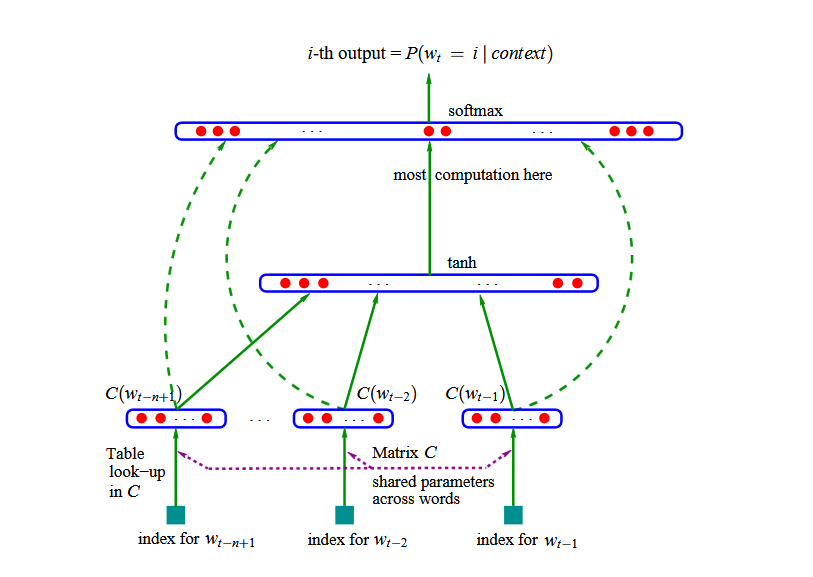

In [111]:
C = torch.rand((27,2)) #look-up table'ımız

In [112]:
C[5]

tensor([0.3527, 0.2306])

# **2. Gizli katmanı ve çıkış katmanını kur: embedding'leri düzleştir, W1 ve b1 ile tanh, W2 ve b2 ile logits. Loss'u geçen haftaki gibi elle hesapla, sonra F.cross_entropy ile aynı sonucu aldığını göster ve neden onu tercih ettiğimizi videodan anla. (18:35 - 37:56)**

In [113]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

In [114]:
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

In [115]:
#emb @ W1 + b1 # bu çalışmıyor çünkü 32,3,2 lik matrisle 6,100 lük matrisi mat mul yapamıyoruz. o yüzden bu C[X] leri birleştirmemiz lazım.

In [116]:
torch.cat([emb[:,0,:], emb[:,1,:], emb[:,2,:]], 1).shape
#bu sayede 32,3,2 lik tensorun son iki kısmını birleştirerek 32,6 lık bir tensor yaptık. Ama bu kullanışlı değil çünkü biz block size 3 için yaptık bunu. block size i degistirmek istediğimizde bunu da sürekli degistirmemiz gerekecek.

torch.Size([32, 6])

In [117]:
torch.cat(torch.unbind(emb, 1), 1).shape

torch.Size([32, 6])

unbind fonksiyonu block size ne olursa olsun çalışacak. ama daha da kullanışlı bir şey yapabiliriz

In [118]:
a = torch.arange(18)
a

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17])

In [119]:
a.shape

torch.Size([18])

In [120]:
a.view(3, 3, 2)

tensor([[[ 0,  1],
         [ 2,  3],
         [ 4,  5]],

        [[ 6,  7],
         [ 8,  9],
         [10, 11]],

        [[12, 13],
         [14, 15],
         [16, 17]]])

In [121]:
a.storage() # aslında pytorch bunları hep 1 boyutlu vektör gibi tutuyor. ama view diye çağırdığımızda bunun verilen parametrelere göre nasıl bir vektor olarak gozukmesi gerektiğini gösteriyor.

 0
 1
 2
 3
 4
 5
 6
 7
 8
 9
 10
 11
 12
 13
 14
 15
 16
 17
[torch.storage.TypedStorage(dtype=torch.int64, device=cpu) of size 18]

In [122]:
emb.view(32,6) == torch.cat(torch.unbind(emb, 1), 1) # gördügünüz gibi ikisi de aynı şey

tensor([[True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, T

In [123]:
#şimdi mat mul yaparken aldığımız hatayı çözelim

h = torch.tanh(emb.view(-1,6) @ W1 + b1) # bu bizim hidden layer'ımız

In [124]:
h

tensor([[ 0.8591,  0.9132,  0.9580,  ..., -0.0683,  0.9187,  0.5220],
        [ 0.7294,  0.9890,  0.3894,  ...,  0.5594,  0.8459, -0.3638],
        [ 0.8166,  0.9257,  0.9202,  ..., -0.6594, -0.3346,  0.2380],
        ...,
        [ 0.9964,  0.6129,  0.8083,  ..., -0.0269,  0.8623,  0.0358],
        [ 0.9177,  0.8629,  0.9768,  ..., -0.6805,  0.7853,  0.7780],
        [ 0.9962,  0.9005, -0.3402,  ...,  0.5290,  0.8198, -0.4955]])

In [125]:
h.shape

torch.Size([32, 100])

In [126]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [127]:
logits = h @ W2 + b2

In [128]:
logits.shape

torch.Size([32, 27])

In [129]:
counts = logits.exp()

In [130]:
prob = counts / counts.sum(1, keepdims=True)

In [131]:
prob.shape

torch.Size([32, 27])

In [132]:
loss = -prob[torch.arange(32), Y].log().mean()
loss

tensor(18.3218)

daha duzenli bir formatta

In [133]:
X.shape, Y.shape # dataset

(torch.Size([32, 3]), torch.Size([32]))

In [134]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [135]:
sum(p.nelement() for p in parameters) # number of parameters in total

3481

In [136]:
emb = C[X] # (32,3,2)
h = torch.tanh(emb.view(-1,6) @ W1 + b1) # (32,100)
logits = h @ W2 + b2 # (32,27)
#counts = logits.exp()
#prob = counts / counts.sum(1, keepdims=True)
#loss = -prob[torch.arange(32), Y].log().mean()
loss = F.cross_entropy(logits, Y)
loss

tensor(17.7697)

burada o 3 satırı yazmak yerine cross entropy kullanmamızın sebebi, pytorch cross entropy fonksiyonu ile o 3 satır kodun yaptığı işi tek hamlede yapabilir. bu sayede o 3 satırlık kodda anlık olarak ekstradan tensorler oluşturmamış oluruz. ve memory şişmez :D

Ve hem forward pass hem de backward pass daha verimli yapılabilir cross entropy ile.

O 3 satır kodda şununla karşılaşabilirdik :

şans eseri bir logit 100 olabilirdi. ve float 32 nin tutabildiği maks sayı 3.4 * 10^38 olduğu için; logits.exp()yaptığımızda sınırın dışında bir sayı hesaplmaya çalıştıgımız icin sonuc inf çıkardı. buna overflow deniyor.

Aynı şekilde logit çok negatif bir değer alırsa yine bu sefer -inf çıkabilirdi. bu da underflow oluyor.

ve

Softmax'in matematiksel bir özelliği vardır : tüm girdilerden sabit bir sayı çıkarırsak çıkan olasılıklar gram değişmez.

Cross entropy burada şöyle bir trick yapıyor :

vektördeki en büüyk logiti bulup tüm logitlerden bu değeri çıkarır. Bu sayede en büyük logit 0 olur ve overflow'a yakalanma şansımız kalmaz.


  Ve F.cross_entropy tek bir C++/CUDA çekirdeğidir (fused kernel). Hiçbir ara tensörü VRAM'e yazmaz. En can
  alıcı nokta ise türevinin zarafetidir:

    ∂L
    ─── = pᵢ - yᵢ
    ∂zᵢ

  (Modelin tahmin ettiği olasılık - Gerçek hedef)

  Geriye yayılımda onlarca zincirleme türev hesabı yapmak yerine, tek bir çıkarma işlemiyle (pᵢ - yᵢ) doğrudan
  logitlerin gradyanını hesaplar ve geçer. Hem inanılmaz hızlıdır, hem bellek harcamaz, hem de asla nan üretmez.

In [137]:
for p in parameters:
  p.requires_grad = True

In [138]:
for _ in range(10):
  #forward pass
  emb = C[X] # (32,3,2)
  h = torch.tanh(emb.view(-1,6) @ W1 + b1) # (32,100)
  logits = h @ W2 + b2 # (32,27)
  loss = F.cross_entropy(logits, Y)
  print(loss.item())
  #backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  #update
  for p in parameters:
    p.data += -0.1 * p.grad

17.76971435546875
13.656401634216309
11.298768997192383
9.452455520629883
7.984262466430664
6.891321182250977
6.100014686584473
5.452036380767822
4.898151874542236
4.414664268493652


Yukarıda loss'umuz harika bir şekilde düşüyor. ama biz burada 32 example için 3481 parametre kullanıyoruz ve overfit yapıyoruz. ve loss hiçbir şekilde 0 a çok yakın olmayacak çünkü biz 5 kelimelik bir örnek aldık ve orada hepsinin başlangıcı ... -> e
... -> o şeklinde. hepsi ... ile başlıyor ve sonrasında kelimenin ilk harfi geliyor. mesela o 5 kelimelik örnekte sadece bir tane oli olduğu için model oli -> v yi doğru şekilde tahmin edebiliyor. yani aslında başlangıçlar hariç her durumun sadece 1 örneği olduğundan model overfit oluyor ve aynı zamanda 0'a çok yakınlaşamıyor. bu yüzden 5 kelime yerine tüm dataseti kullanalım şimdi
  

# **3. Eğitim döngüsünü kur: önce tek bir minibatch'i overfit et, sonra bütün veriyi minibatch'lerle eğit. Learning rate'i videodaki gibi tara ve iyi bir değer seç. Veriyi train / dev / test olarak böl, loss'u dev üzerinde raporla. (37:56 - 1:00:49)**

In [139]:
# build the dataset

block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], [] #input ve label'lar
for w in words:

  #print(w)
  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    #print(''.join(itos[i] for i in context), '--->', itos[ix])
    context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

In [140]:
X.shape, Y.shape # dataset

(torch.Size([228146, 3]), torch.Size([228146]))

In [141]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [142]:
sum(p.nelement() for p in parameters) # number of parameters in total

3481

In [143]:
for p in parameters:
  p.requires_grad = True

In [144]:
for _ in range(100):
  #minibatch construct
  ix = torch.randint(0, X.shape[0], (32,))

  #forward pass
  emb = C[X[ix]] # (32,3,2)
  h = torch.tanh(emb.view(-1,6) @ W1 + b1) # (32,100)
  logits = h @ W2 + b2 # (32,27)
  loss = F.cross_entropy(logits, Y[ix])
  print(loss.item())
  #backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  #update
  for p in parameters:
    p.data += -0.1 * p.grad

19.39493751525879
19.027719497680664
14.044853210449219
17.163532257080078
14.406106948852539
14.207006454467773
13.95245361328125
10.889286994934082
10.943061828613281
12.242722511291504
12.37100887298584
10.299249649047852
9.347620010375977
7.2143330574035645
8.232556343078613
9.163023948669434
9.162678718566895
9.603303909301758
8.796012878417969
10.456428527832031
10.648595809936523
8.857656478881836
8.290586471557617
6.7571187019348145
8.380109786987305
9.09069538116455
6.554300308227539
6.314512729644775
7.478044033050537
7.8935112953186035
5.620779991149902
6.195357799530029
6.971004009246826
5.596724987030029
5.911819934844971
5.266846656799316
6.399989604949951
4.613345146179199
6.045633316040039
6.562735557556152
6.61838436126709
5.441516399383545
5.579855442047119
5.138020038604736
5.9859819412231445
5.199069499969482
4.869072437286377
7.064700126647949
5.274771690368652
4.4063520431518555
6.765811443328857
4.865152835845947
5.1013383865356445
5.816219329833984
4.22761487960

In [145]:
torch.randint(0, 5, (32,)) # 0-5 aralığında 32 tane sayı ürettik

tensor([1, 0, 4, 0, 0, 1, 0, 4, 1, 4, 2, 2, 4, 4, 0, 4, 3, 4, 0, 1, 1, 3, 2, 1,
        3, 3, 0, 2, 4, 1, 2, 4])

fullbatch'te bir ağırlığı güncellemek için 228000 örneğin tamamını forward pass sonra backward pass geçirmek zorundayız. bunun sonucunda elde ettiğimiz gradyan pürüssüz ve %100 doğrudur.

minibatch'te mesela rastgele 32 örnek seçerek gradyanı buna göre hesaplarız. Burada hesapladığımız gradyan bir tahmin edicidir. noise barındırır ama yönü kabaca doğrudur.

Fullbatch ile 1 adım atacağımız sürede minibatch ile yüzlerce adım atarak loss'u hızla aşağı indirebiliriz.

Aynı zamanda minibatch inanılmaz bir GPU VRAM avantajı sağlar. Çünkü 228000 örneğin hidden layerlarındaki ara tensörleri bellekte tutmuyoruz.

Aynı zamanda minibatchin ürettiği o tahmin edici gradyan bizim local minimumlara takılmamızı engeller.

In [146]:
#şimdi optimizasyon ksımına geçelim ve gerçek loss ile çalışalım.

emb = C[X] # (32,3,2)
h = torch.tanh(emb.view(-1,6) @ W1 + b1) # (32,100)
logits = h @ W2 + b2 # (32,27)
loss = F.cross_entropy(logits, Y)
loss

tensor(3.6980, grad_fn=<NllLossBackward0>)

yukarıda lr yi 0.1 seçmiştik. ama hangi lr'nin bizim için en iyi olduğunu bilmiyourz. o yüzden lr sweep test yapacağız.

In [147]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre
#lrs

şimdi parametreleri sıfırlayıp en baştan bu lrler ile lossu düşürmeye çalışalım.  

In [148]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [149]:
for p in parameters:
  p.requires_grad = True

In [150]:
lri = []
lossi = []

for i in range(1000):
  #minibatch construct
  ix = torch.randint(0, X.shape[0], (32,))

  #forward pass
  emb = C[X[ix]] # (32,3,2)
  h = torch.tanh(emb.view(-1,6) @ W1 + b1) # (32,100)
  logits = h @ W2 + b2 # (32,27)
  loss = F.cross_entropy(logits, Y[ix])
  print(loss.item())

  #backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  #update
  lr = lrs[i]
  for p in parameters:
    p.data += -lr * p.grad

  #track stats
  lri.append(lre[i])
  lossi.append(loss.item())

21.5004825592041
17.559009552001953
17.089092254638672
19.91146469116211
20.01444435119629
19.612028121948242
18.414016723632812
20.8400936126709
19.918048858642578
21.25267219543457
15.291158676147461
18.754606246948242
20.586463928222656
20.28680419921875
19.207677841186523
19.7114315032959
18.293298721313477
17.210556030273438
20.04476547241211
18.367380142211914
18.07921600341797
16.770652770996094
20.25937843322754
17.643085479736328
19.746810913085938
15.770906448364258
13.608674049377441
21.746267318725586
19.163780212402344
20.550552368164062
18.84694480895996
17.059722900390625
16.976367950439453
18.503311157226562
18.894765853881836
17.013580322265625
19.51939582824707
18.541728973388672
19.93380355834961
18.049022674560547
17.729562759399414
17.38530921936035
19.647281646728516
18.600618362426758
18.07865333557129
16.909828186035156
20.801992416381836
19.110244750976562
17.568042755126953
18.906179428100586
18.186229705810547
17.579172134399414
17.85003662109375
18.193151473

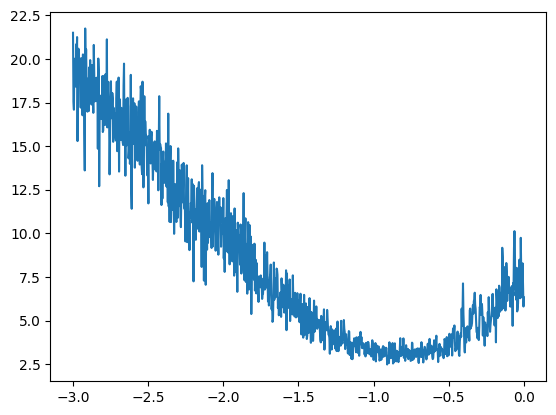

In [151]:
plt.plot(lri, lossi)

yukarıdaki grafikte eksponent olarak en iyi loss'u veren eksponent'in yaklaşık -1.0 olduğunu görüyoruz. yani en iyi lr 0.1 miş. şimdi lr'yi elle 0.1 olarak ayarlayıp en baştan tekrar train edelim.  

In [152]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [153]:
for p in parameters:
  p.requires_grad = True

In [154]:
lri = []
lossi = []

for i in range(10000):
  #minibatch construct
  ix = torch.randint(0, X.shape[0], (32,))

  #forward pass
  emb = C[X[ix]] # (32,3,2)
  h = torch.tanh(emb.view(-1,6) @ W1 + b1) # (32,100)
  logits = h @ W2 + b2 # (32,27)
  loss = F.cross_entropy(logits, Y[ix])
  #print(loss.item())

  #backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  #update
  #lr = lrs[i]
  for p in parameters:
    p.data += -0.1 * p.grad

  #track stats
  #lri.append(lre[i])
  #lossi.append(loss.item())

In [155]:
#şimdi optimizasyon ksımına geçelim ve gerçek loss ile çalışalım.

emb = C[X] # (32,3,2)
h = torch.tanh(emb.view(-1,6) @ W1 + b1) # (32,100)
logits = h @ W2 + b2 # (32,27)
loss = F.cross_entropy(logits, Y)
loss

tensor(2.4831, grad_fn=<NllLossBackward0>)

train val test split kısmı

In [156]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [157]:
Xtr.shape, Ytr.shape #dataset

(torch.Size([182625, 3]), torch.Size([182625]))

In [158]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [159]:
for p in parameters:
  p.requires_grad = True

In [160]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre
#lrs

In [161]:
lri = []
lossi = []

for i in range(10000):
  #minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (32,))

  #forward pass
  emb = C[Xtr[ix]] # (32,3,2)
  h = torch.tanh(emb.view(-1,6) @ W1 + b1) # (32,100)
  logits = h @ W2 + b2 # (32,27)
  loss = F.cross_entropy(logits, Ytr[ix])
  #print(loss.item())

  #backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  #update
  #lr = lrs[i]
  for p in parameters:
    p.data += -0.1 * p.grad

  #track stats
  #lri.append(lre[i])
  #lossi.append(loss.item())

In [162]:
print(loss.item())

2.4081997871398926


şimdi dev için lossa bakalım

In [163]:
emb = C[Xdev] # (32,3,2)
h = torch.tanh(emb.view(-1,6) @ W1 + b1) # (32,100)
logits = h @ W2 + b2 # (32,27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.4957, grad_fn=<NllLossBackward0>)

In [164]:
sum(p.nelement() for p in parameters) # number of parameters in total

3481

Gördüğümüz üzere train ve dev lossları neredeyse aynı. bu underfit ettiğimiz anlamına geliyor. ve loss'umuz hala  çok düşük değil. sadece 3481 parametre kullanıyoruz. bu, neural net'i daha derinleştirmemiz anlamına geliyor.

In [165]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 300), generator=g)
b1 = torch.randn(300, generator=g)
W2 = torch.randn((300, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [166]:
sum(p.nelement() for p in parameters) # number of parameters in total

10281

In [167]:
for p in parameters:
  p.requires_grad = True

In [168]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre
#lrs

In [169]:
lri = []
lossi = []
stepi = []

for i in range(30000):
  #minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (32,))

  #forward pass
  emb = C[Xtr[ix]] # (32,3,2)
  h = torch.tanh(emb.view(-1,6) @ W1 + b1) # (32,100)
  logits = h @ W2 + b2 # (32,27)
  loss = F.cross_entropy(logits, Ytr[ix])
  #print(loss.item())

  #backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  #update
  #lr = lrs[i]
  for p in parameters:
    p.data += -0.1 * p.grad

  #track stats
  #lri.append(lre[i])
  stepi.append(i)
  lossi.append(loss.item())

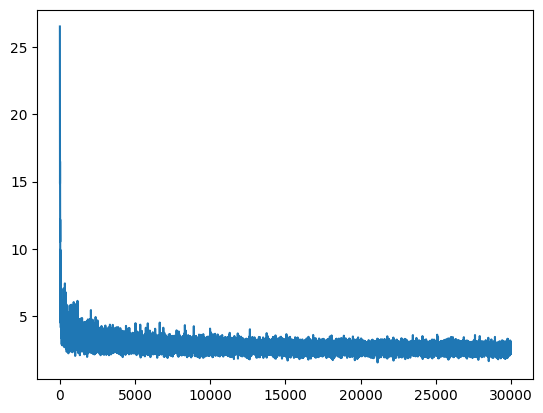

In [170]:
plt.plot(stepi, lossi)

şimdi biraz daha train edelim parametre sıfırlamadan

In [171]:
emb = C[Xtr] # (32,3,2)
h = torch.tanh(emb.view(-1,6) @ W1 + b1) # (32,100)
logits = h @ W2 + b2 # (32,27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.7918, grad_fn=<NllLossBackward0>)

# **4. Gizli katmanı ve embedding boyutunu büyütüp dev loss'un nasıl değiştiğini göster. Embedding'leri 2 boyutta çizdir: hangi harfler birbirine yakın düşüyor? Modelden isimler örnekle, bigram'ınkilerle karşılaştır. (1:00:49 - 1:13:24)**

hidden layerı genişletmek aslında çok işe yaramadı. bir darboğaz meydana geldi çünkü bizim embeddinglerimiz 2 boyutlu. embeddingleri bir görselleştirelim

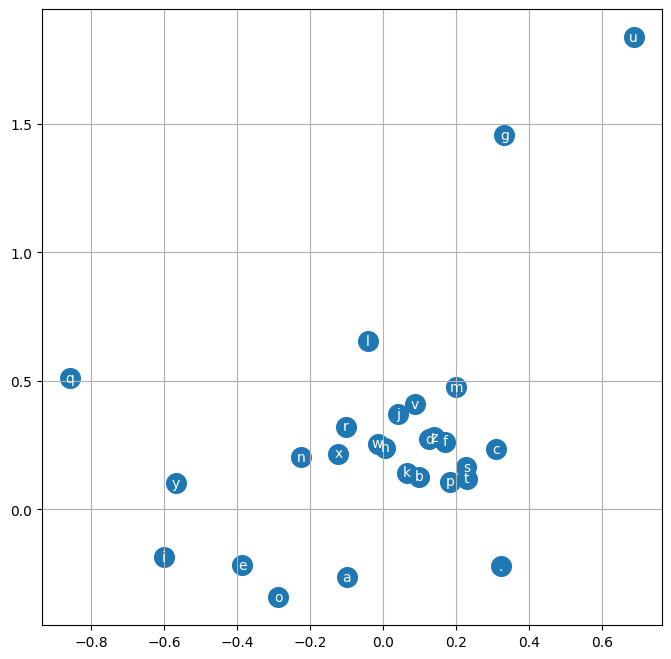

In [172]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

şimdi embedding'imizi 2 boyut yerine 10 boyutlu yapalım ve o darboğazı yenmeye çalışalım.

In [173]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [174]:
sum(p.nelement() for p in parameters) # number of parameters in total

11897

In [175]:
for p in parameters:
  p.requires_grad = True

In [176]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre
#lrs

In [177]:
lri = []
lossi = []
stepi = []

In [178]:
for i in range(50000):
  #minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (32,))

  #forward pass
  emb = C[Xtr[ix]] # (32,3,2)
  h = torch.tanh(emb.view(-1,30) @ W1 + b1) # (32,100)
  logits = h @ W2 + b2 # (32,27)
  loss = F.cross_entropy(logits, Ytr[ix])
  #print(loss.item())

  #backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  #update
  #lr = lrs[i]
  for p in parameters:
    p.data += -0.1 * p.grad

  #track stats
  #lri.append(lre[i])
  stepi.append(i)
  lossi.append(loss.log10().item())

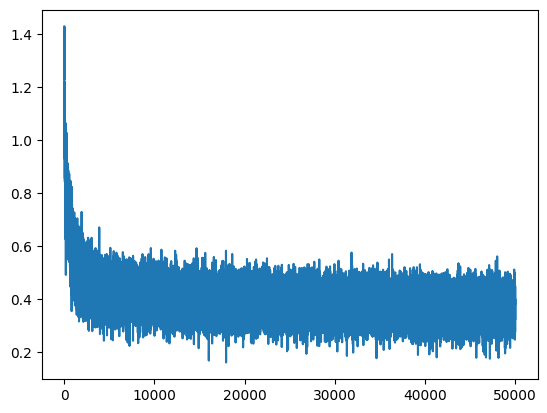

In [179]:
plt.plot(stepi, lossi)

In [180]:
emb = C[Xtr] # (32,3,2)
h = torch.tanh(emb.view(-1,30) @ W1 + b1) # (32,100)
logits = h @ W2 + b2 # (32,27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.3655, grad_fn=<NllLossBackward0>)

In [181]:
emb = C[Xdev] # (32,3,2)
h = torch.tanh(emb.view(-1,30) @ W1 + b1) # (32,100)
logits = h @ W2 + b2 # (32,27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.3954, grad_fn=<NllLossBackward0>)

In [182]:
context = [0] * block_size
C[torch.tensor([context])].shape

torch.Size([1, 3, 10])

In [183]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break

    print(''.join(itos[i] for i in out))

chriah.
ameri.
kih.
jmre.
hev.
cheranshal.
mahner.
den.
rhcis.
emi.
nerania.
chrihvin.
negy.
hhli.
forn.
essan.
shon.
maria.
bino.
zerox.
